# 01 Exploration

Load all local CRMLS sold CSV files from `data/raw/` and run initial exploration for the California close price prediction project.

In [165]:
# Import Libraries
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

# 1. Dataset Overview

### Load Data

In [166]:
# Load every local CRMLS sold CSV file.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

csv_files = sorted(RAW_DATA_DIR.glob("CRMLSSold*.csv"))

print(f"Found {len(csv_files)} CRMLSSold CSV files")

for path in csv_files:
    print(path.name)

Found 6 CRMLSSold CSV files
CRMLSSold202512.csv
CRMLSSold202601.csv
CRMLSSold202602.csv
CRMLSSold202603.csv
CRMLSSold202604.csv
CRMLSSold202605.csv


In [167]:
# Load a CRMLS CSV and add source_file so each row can be traced back to its original file.
def load_crmls_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    df["source_file"] = path.name
    return df


# Store each monthly file separately first, then concatenate into one analysis DataFrame.
dataframes = []
file_summary = []

for path in csv_files:
    df = load_crmls_file(path)
    dataframes.append(df)

    # Keep a compact file-level summary to check row counts and schema consistency across files.
    file_summary.append(
        {
            "source_file": path.name,
            "rows": len(df),
            "columns": df.shape[1],
        }
    )

# Combine all monthly files into one raw dataset.
raw_df = pd.concat(dataframes, ignore_index=True)
file_summary_df = pd.DataFrame(file_summary)

print(f"Combined shape: {raw_df.shape}")
file_summary_df

Combined shape: (124404, 79)


,source_file,rows,columns
0,CRMLSSold202512.csv,20538,79
1,CRMLSSold202601.csv,16487,79
2,CRMLSSold202602.csv,18124,79
3,CRMLSSold202603.csv,22583,79
4,CRMLSSold202604.csv,23412,79
5,CRMLSSold202605.csv,23260,79


In [168]:
# Inspect column names, inferred dtypes, non-null counts, and approximate memory usage.
raw_df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 124404 entries, 0 to 124403
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 118347 non-null  str    
 1   ListAgentAOR                  124358 non-null  str    
 2   Flooring                      72408 non-null   str    
 3   ViewYN                        112237 non-null  object 
 4   WaterfrontYN                  83 non-null      object 
 5   BasementYN                    1979 non-null    object 
 6   PoolPrivateYN                 110682 non-null  object 
 7   OriginalListPrice             124042 non-null  float64
 8   ListingKey                    124404 non-null  int64  
 9   ListAgentEmail                124134 non-null  str    
 10  CloseDate                     124404 non-null  str    
 11  ClosePrice                    124403 non-null  float64
 12  ListAgentFirstName            123903 non-null  str    


### Filter to Project Scope

The task prompt says to model only records where `PropertyType == "Residential"` and `PropertySubType == "SingleFamilyResidence"`.

In [169]:
# Check the main filtering fields.
for col in ["PropertyType", "PropertySubType", "MlsStatus"]:
    if col in raw_df.columns:
        display(raw_df[col].value_counts(dropna=False).head(20).to_frame("count"))

,count
PropertyType,
Residential,82643
ResidentialLease,29673
Land,4012
ResidentialIncome,3381
ManufacturedInPark,3186
CommercialSale,805
CommercialLease,638
BusinessOpportunity,66


,count
PropertySubType,
SingleFamilyResidence,75250
Condominium,21716
NaN,9185
Townhouse,7207
Apartment,3431
Duplex,2505
ManufacturedOnLand,1227
Triplex,854
Quadruplex,786


,count
MlsStatus,
Closed,124404


In [170]:
# Filter the dataset.
df = raw_df[
    (raw_df["PropertyType"] == "Residential") &
    (raw_df["PropertySubType"].astype(str).str.replace(" ", "", regex=False) == "SingleFamilyResidence")
].copy()


print(f"Original rows: {raw_df.shape[0]:,}")
print(f"Filtered rows: {df.shape[0]:,}")
print(f"Remaining ratio: {df.shape[0] / raw_df.shape[0]:.2%}")

Original rows: 124,404
Filtered rows: 61,727
Remaining ratio: 49.62%


# 2. Check Target variable: ClosePrice

In [171]:
# Convert the target variable to numeric.
df["ClosePrice"] = pd.to_numeric(df["ClosePrice"], errors="coerce")

In [172]:
# Check whether the target has missing, invalid, or non-positive values.
print(f"Number of missing values in ClosePrice: {df['ClosePrice'].isna().sum()}")
print(f"Number of non-positive values in ClosePrice: {(df['ClosePrice'] <= 0).sum()}")
print(f"Description of ClosePrice:\n{df['ClosePrice'].describe()}")

Number of missing values in ClosePrice: 0
Number of non-positive values in ClosePrice: 0
Description of ClosePrice:
count    6.172700e+04
mean     1.340106e+06
std      7.307629e+06
min      1.750000e+00
25%      6.200000e+05
50%      8.900000e+05
75%      1.425000e+06
max      7.960000e+08
Name: ClosePrice, dtype: float64


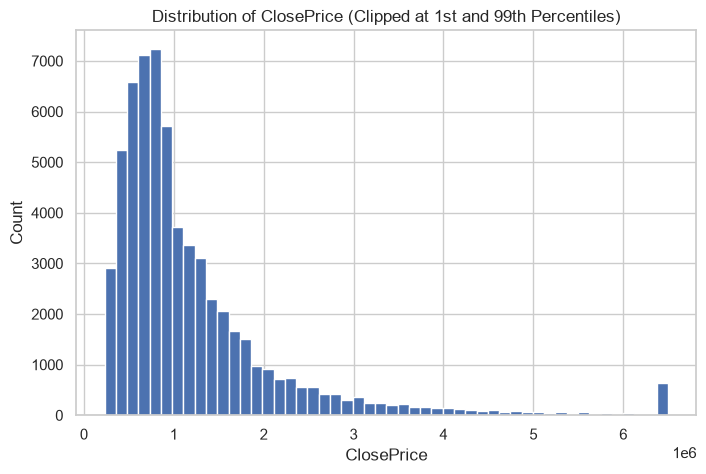

In [173]:
# Use percentile clipping only for plotting the target distribution.
# This keeps extreme luxury sales from compressing the main body of the histogram.
lower = df["ClosePrice"].quantile(0.01)
upper = df["ClosePrice"].quantile(0.99)

plt.figure(figsize=(8, 5))
df["ClosePrice"].dropna().clip(lower, upper).hist(bins=50)
plt.xlabel("ClosePrice")
plt.ylabel("Count")
plt.title("Distribution of ClosePrice (Clipped at 1st and 99th Percentiles)")
plt.show()

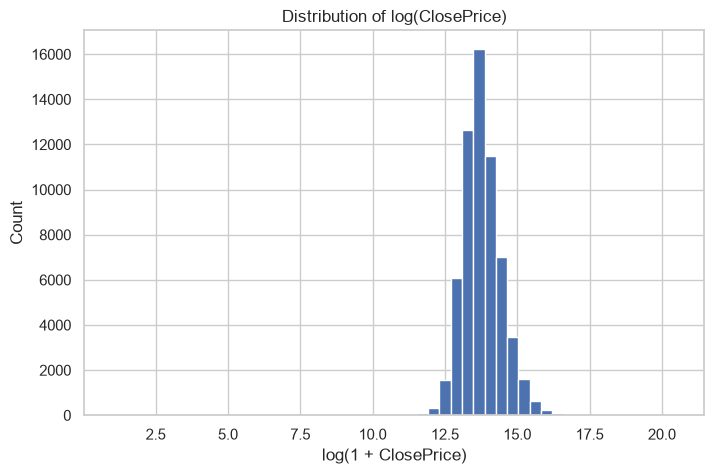

In [174]:
# Plot log-transformed ClosePrice to see whether the target becomes more symmetric.
# log1p is commonly used for right-skewed price targets.
plt.figure(figsize=(8, 5))
np.log1p(df["ClosePrice"].dropna()).hist(bins=50)
plt.xlabel("log(1 + ClosePrice)")
plt.ylabel("Count")
plt.title("Distribution of log(ClosePrice)")
plt.show()

# 3. Data Quality Checks

### Duplicate ListingKey

In [175]:
# Count duplicate ListingKey rows.
# ListingKey should generally identify one listing, so duplicates need follow-up before modeling.
df["ListingKey"].duplicated().sum()

np.int64(33)

In [176]:
# Summarize duplicate ListingKeys
# n_rows: how many records share the same key
# n_files: whether duplicates span files
duplicated_listing_keys = (
    df.dropna(subset=["ListingKey"])
    .groupby("ListingKey")
    .agg(
        n_rows=("ListingKey", "size"),
        n_files=("source_file", "nunique"),
        files=("source_file", lambda x: ", ".join(sorted(x.unique()))),
    )
    .query("n_rows > 1")
    .sort_values(["n_rows", "n_files"], ascending=False)
)

print(f"Number of ListingKeys with duplicate rows: {len(duplicated_listing_keys):,}")
print(f"Number of extra rows caused by duplicated ListingKeys: {(duplicated_listing_keys['n_rows'] - 1).sum():,}")

# Classify duplicates (repeated within a single file or repeated across multiple files).
duplicate_type_summary = (
    duplicated_listing_keys.assign(
        duplicate_type=lambda x: x["n_files"].gt(1).map(
            {True: "across_files", False: "within_same_file"}
        )
    )["duplicate_type"]
    .value_counts()
    .to_frame("n_listing_keys")
)

# Display a summary and examples.
display(duplicate_type_summary)
display(duplicated_listing_keys.head(20))

Number of ListingKeys with duplicate rows: 33
Number of extra rows caused by duplicated ListingKeys: 33


,n_listing_keys
duplicate_type,
across_files,31
within_same_file,2


,n_rows,n_files,files
ListingKey,,,
1107335546,2,2,"CRMLSSold202601.csv, CRMLSSold202604.csv"
1108963864,2,2,"CRMLSSold202601.csv, CRMLSSold202604.csv"
1118281460,2,2,"CRMLSSold202602.csv, CRMLSSold202603.csv"
1118859284,2,2,"CRMLSSold202601.csv, CRMLSSold202602.csv"
1125615193,2,2,"CRMLSSold202602.csv, CRMLSSold202603.csv"
1135646820,2,2,"CRMLSSold202603.csv, CRMLSSold202605.csv"
1137564166,2,2,"CRMLSSold202512.csv, CRMLSSold202601.csv"
1138529088,2,2,"CRMLSSold202512.csv, CRMLSSold202601.csv"
1139401118,2,2,"CRMLSSold202512.csv, CRMLSSold202601.csv"


In [177]:
# Pull the full duplicate rows so we can compare whether important fields differ.
duplicated_key_values = duplicated_listing_keys.index
duplicated_rows = df[df["ListingKey"].isin(duplicated_key_values)].copy()

# Keep only fields that help diagnose whether duplicates are exact repeats or updated records.
columns_to_compare = [
    "source_file",
    "CloseDate",
    "ClosePrice",
    "MlsStatus",
    "ListPrice",
    "PropertyType",
    "PropertySubType",
    "UnparsedAddress",
    "City",
    "PostalCode",
]
columns_to_compare = [col for col in columns_to_compare if col in duplicated_rows.columns]

# Count how many distinct values each duplicated ListingKey has in key fields.
# Values greater than 1 mean that the duplicate rows are not identical in that field.
variation_summary = (
    duplicated_rows.groupby("ListingKey")
    .agg(
        n_rows=("ListingKey", "size"),
        n_files=("source_file", "nunique"),
        n_close_dates=("CloseDate", "nunique"),
        n_close_prices=("ClosePrice", "nunique"),
        n_statuses=("MlsStatus", "nunique"),
        n_list_prices=("ListPrice", "nunique"),
    )
    .sort_values(["n_close_prices", "n_close_dates", "n_rows"], ascending=False)
)

display(variation_summary.head(20))

# Show one concrete example so the duplicate pattern can be inspected manually.
if len(variation_summary) > 0:
    sample_key = variation_summary.index[0]
    print(f"Sample duplicated ListingKey: {sample_key}")
    display(
        duplicated_rows.loc[
            duplicated_rows["ListingKey"] == sample_key,
            ["ListingKey"] + columns_to_compare,
        ].sort_values(["source_file", "CloseDate"])
    )

,n_rows,n_files,n_close_dates,n_close_prices,n_statuses,n_list_prices
ListingKey,,,,,,
1118859284,2,2,2,2,1,1
1137564166,2,2,2,2,1,1
1144635053,2,2,2,2,1,1
1145660298,2,2,2,2,1,1
1149466652,2,2,2,2,1,1
1150500971,2,2,2,2,1,1
1151430127,2,2,2,2,1,1
1153193563,2,2,2,2,1,2
1153596424,2,2,2,2,1,1


Sample duplicated ListingKey: 1118859284


,ListingKey,source_file,CloseDate,ClosePrice,MlsStatus,ListPrice,PropertyType,PropertySubType,UnparsedAddress,City,PostalCode
35782,1118859284,CRMLSSold202601.csv,2026-01-16,875000.0,Closed,870000.0,Residential,SingleFamilyResidence,5599 Skimmer Drive,Jurupa Valley,91752
54197,1118859284,CRMLSSold202602.csv,2026-02-06,874400.0,Closed,870000.0,Residential,SingleFamilyResidence,5599 Skimmer Drive,Jurupa Valley,91752


### Coordinates

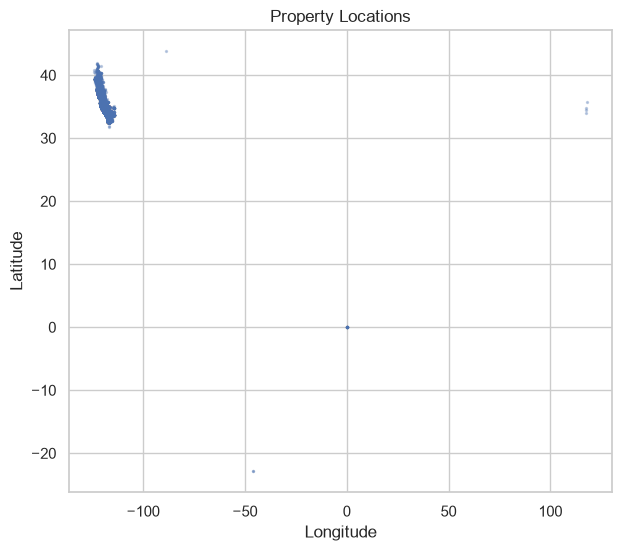

In [178]:
# Quick coordinate scatter plot to confirm the records are located in California.
plt.figure(figsize=(7, 6))
plt.scatter(df["Longitude"], df["Latitude"], s=2, alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Property Locations")
plt.show()

In [179]:
display(df[["Latitude", "Longitude"]].describe())

# Flag coordinates outside the expected California range.
# These records may need to be removed or have coordinates set to missing before modeling.
ca_lat_min, ca_lat_max = 32.0, 42.5
ca_lon_min, ca_lon_max = -125.0, -114.0

outside_ca = df[
    (df["Latitude"] < ca_lat_min) |
    (df["Latitude"] > ca_lat_max) |
    (df["Longitude"] < ca_lon_min) |
    (df["Longitude"] > ca_lon_max)
]

print(f"Number of properties outside California: {outside_ca.shape[0]}")

,Latitude,Longitude
count,61718.000000,61718.000000
mean,34.708615,-118.560570
std,1.802984,3.253774
min,-22.863239,-124.175789
25%,33.753896,-119.063627
50%,34.077918,-118.017017
75%,34.695388,-117.250670
max,43.784440,118.140030


Number of properties outside California: 24


In [199]:
# Review Coordinate Outliers
# Inspect the location fields for records outside the expected California coordinate range.
# If City/County/ZIP/address are still valid, it is usually better to keep the row
# and only flag or null out the bad coordinate values during preprocessing.
coordinate_review_cols = [
    "ListingKey",
    "CloseDate",
    "City",
    "CountyOrParish",
    "PostalCode",
    "Latitude",
    "Longitude",
    "UnparsedAddress",
    "ClosePrice",
    "source_file",
]

available_coordinate_review_cols = [col for col in coordinate_review_cols if col in outside_ca.columns]

outside_ca_review = (
    outside_ca[available_coordinate_review_cols]
    .sort_values(["CountyOrParish", "City", "PostalCode", "CloseDate"], na_position="last")
    .reset_index(drop=True)
)

print(f"Coordinate outlier rows: {outside_ca_review.shape[0]}")

if "CountyOrParish" in outside_ca_review.columns:
    print("\nCounty counts:")
    display(outside_ca_review["CountyOrParish"].value_counts(dropna=False).to_frame("count"))

if "City" in outside_ca_review.columns:
    print("\nCity counts:")
    display(outside_ca_review["City"].value_counts(dropna=False).to_frame("count"))

display(outside_ca_review)

Coordinate outlier rows: 24

County counts:


,count
CountyOrParish,
Monterey,9
Los Angeles,4
San Benito,3
San Bernardino,2
Foreign Country,1
Fresno,1
Napa,1
Other State,1
Riverside,1



City counts:


,count
City,
Marina,7
Hollister,3
Other,2
Lancaster,2
Carmel,2
Fresno,1
Palmdale,1
Pomona,1
Napa,1


,ListingKey,CloseDate,City,CountyOrParish,PostalCode,Latitude,Longitude,UnparsedAddress,ClosePrice,source_file
0,1099893565,2025-12-05,Other,Foreign Country,22785,31.786721,-116.608868,"239 73 Arena Brillante, Ensenada, Baja, Mexico",200000.0,CRMLSSold202512.csv
1,1153563387,2026-04-24,Fresno,Fresno,93701,0.000000,0.000000,2845 Madison,291500.0,CRMLSSold202604.csv
2,1151742468,2026-02-19,Lancaster,Los Angeles,93534,35.691123,118.140030,44515 Date Avenue W,255000.0,CRMLSSold202602.csv
3,1146479685,2026-02-26,Lancaster,Los Angeles,93536,0.000000,0.000000,6116 W Avenue K9,650000.0,CRMLSSold202602.csv
4,1112143463,2025-12-04,Palmdale,Los Angeles,93551,0.000000,0.000000,37849 Satinwood Lane,540000.0,CRMLSSold202512.csv
5,1138492285,2025-12-18,Pomona,Los Angeles,91768,43.784440,-88.787868,1183 Wisconsin,590000.0,CRMLSSold202512.csv
6,1139735858,2026-02-18,Carmel,Monterey,93921,-22.863239,-46.038608,0 SE Corner of Monte Verde & 10th Avenue,4500000.0,CRMLSSold202602.csv
7,1114485540,2026-04-09,Carmel,Monterey,93923,-22.863239,-46.038608,Monte Verde & 13th Avenue,3800000.0,CRMLSSold202604.csv
8,1136784325,2025-12-03,Marina,Monterey,93933,0.000000,0.000000,3080 Arroyo Drive,1532264.0,CRMLSSold202512.csv
9,1140170410,2026-02-23,Marina,Monterey,93933,0.000000,0.000000,605 Santa Ynez Way,1192939.0,CRMLSSold202602.csv


## 4. Missing Values and Candidate Feature Groups

In [180]:
# Calculate missing value rate for every column after filtering to the project scope.
# Keep both a detailed table and a compact grouped summary for presentation.
missing = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
missing.columns = ["column", "missing_rate"]

missing["missing_group"] = pd.cut(
    missing["missing_rate"],
    bins=[-0.01, 0, 0.05, 0.25, 0.50, 0.80, 1.00],
    labels=["0%", "0-5%", "5-25%", "25-50%", "50-80%", "80-100%"],
)

missing_group_summary = (
    missing["missing_group"]
    .value_counts(sort=False)
    .rename_axis("missing_rate_group")
    .reset_index(name="n_columns")
)

# This table is good for slides because it summarizes missingness without listing every column.
display(missing_group_summary)

# Keep the detailed top missing columns for preprocessing decisions.
display(missing.head(30))

,missing_rate_group,n_columns
0,0%,18
1,0-5%,25
2,5-25%,9
3,25-50%,4
4,50-80%,5
5,80-100%,18


,column,missing_rate,missing_group
0,CoveredSpaces,1.000000,80-100%
1,MiddleOrJuniorSchoolDistrict,1.000000,80-100%
2,TaxYear,1.000000,80-100%
3,ElementarySchoolDistrict,1.000000,80-100%
4,BusinessType,1.000000,80-100%
5,TaxAnnualAmount,1.000000,80-100%
6,FireplacesTotal,1.000000,80-100%
7,AboveGradeFinishedArea,1.000000,80-100%
8,WaterfrontYN,0.999417,80-100%
9,BelowGradeFinishedArea,0.992791,80-100%


In [181]:
# Draft feature lists for the next preprocessing/modeling notebook.
drop_cols = [
    # Target
    "ClosePrice",

    # leakage
    "ListPrice",
    "OriginalListPrice",
    "CloseDate",

    # IDs
    "ListingKey",
    "ListingKeyNumeric",
    "ListingId",

    # 100% missing
    "CoveredSpaces",
    "MiddleOrJuniorSchoolDistrict",
    "TaxYear",
    "ElementarySchoolDistrict",
    "BusinessType",
    "TaxAnnualAmount",
    "FireplacesTotal",
    "AboveGradeFinishedArea",

    # Very high missing (> 80%)
    "WaterfrontYN",
    "BelowGradeFinishedArea",
    "BasementYN",
    "BuilderName",
    "LotSizeDimensions",
    "BuildingAreaTotal",
    "CoBuyerAgentFirstName",
    "MiddleOrJuniorSchool",
    "ElementarySchool",
    "HighSchool",

    # Agent / office fields
    "ListAgentEmail",
    "ListAgentFirstName",
    "ListAgentLastName",
    "ListAgentFullName",
    "CoListAgentFirstName",
    "CoListAgentLastName",
    "BuyerAgentFirstName",
    "BuyerAgentLastName",
    "BuyerAgentMlsId",
    "ListOfficeName",
    "BuyerOfficeName",
    "CoListOfficeName",
    "BuyerAgentAOR",
    "ListAgentAOR",
    "BuyerOfficeAOR",

    # Transaction timing / potential leakage for first model
    "PurchaseContractDate",
    "ContractStatusChangeDate",
    "DaysOnMarket",

    # Too sparse or not needed initially
    "SubdivisionName",
    "AssociationFeeFrequency",
    "MainLevelBedrooms",    # 39% missing + 'BedroomsTotal' already provides similar information.
    "StateOrProvince"
]

# Candidate numeric predictors for initial EDA and baseline modeling.
numeric_cols = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "GarageSpaces",
    "ParkingTotal",
    "Stories",
    "AssociationFee"
]

# Boolean-like predictors that may need conversion from strings/YN values before modeling.
boolean_cols = [
    "ViewYN",
    "PoolPrivateYN",
    "AttachedGarageYN",
    "FireplaceYN",
    "NewConstructionYN"
]

# Categorical predictors that may need encoding or rare-category grouping.
categorical_cols = [
    "City",
    "CountyOrParish",
    "PostalCode",
    "MLSAreaMajor",
    "Levels",
    "Flooring",
    "HighSchoolDistrict"
]

### Numeric Feature Summary

In [182]:
# Convert candidate numeric features to numeric dtype.
# Invalid strings become NaN so summaries and plots do not fail.
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

available_numeric_cols = [col for col in numeric_cols if col in df.columns]

# Compact numeric summary for preprocessing decisions.
# Missing rate indicates imputation needs; skew helps decide whether log transforms may be useful.
numeric_summary = df[available_numeric_cols].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max",
]).T

numeric_summary["missing_rate"] = df[available_numeric_cols].isna().mean()
numeric_summary["skew"] = df[available_numeric_cols].skew(numeric_only=True)

# Reorder columns so the most useful EDA fields appear first.
numeric_summary = numeric_summary[
    ["count", "missing_rate", "mean", "median", "std", "min", "max", "skew"]
]

display(numeric_summary)

,count,missing_rate,mean,median,std,min,max,skew
LivingArea,61697.0,0.000486,2055.552918,1826.000000,1.037244e+03,0.000000,2.331400e+04,2.944930
BedroomsTotal,61727.0,0.000000,3.498437,3.000000,9.666841e-01,0.000000,2.200000e+01,0.732116
BathroomsTotalInteger,61726.0,0.000016,2.644801,2.000000,1.135026e+00,0.000000,2.200000e+01,1.804946
LotSizeSquareFeet,60646.0,0.017513,385948.903096,7263.500000,1.843401e+07,0.000000,1.897474e+09,72.808657
YearBuilt,61691.0,0.000583,1976.298390,1977.000000,2.769937e+01,1801.000000,2.026000e+03,-0.177413
Latitude,61718.0,0.000146,34.708615,34.077918,1.802984e+00,-22.863239,4.378444e+01,-1.700979
Longitude,61718.0,0.000146,-118.560570,-118.017017,3.253774e+00,-124.175789,1.181400e+02,36.713596
GarageSpaces,59374.0,0.038119,2.005196,2.000000,3.327872e+00,0.000000,6.000000e+02,138.696007
ParkingTotal,61727.0,0.000000,2.991292,2.000000,1.854424e+01,-16.000000,3.921000e+03,161.958083
Stories,55234.0,0.105189,1.351468,1.000000,4.774332e-01,1.000000,2.000000e+00,0.622232


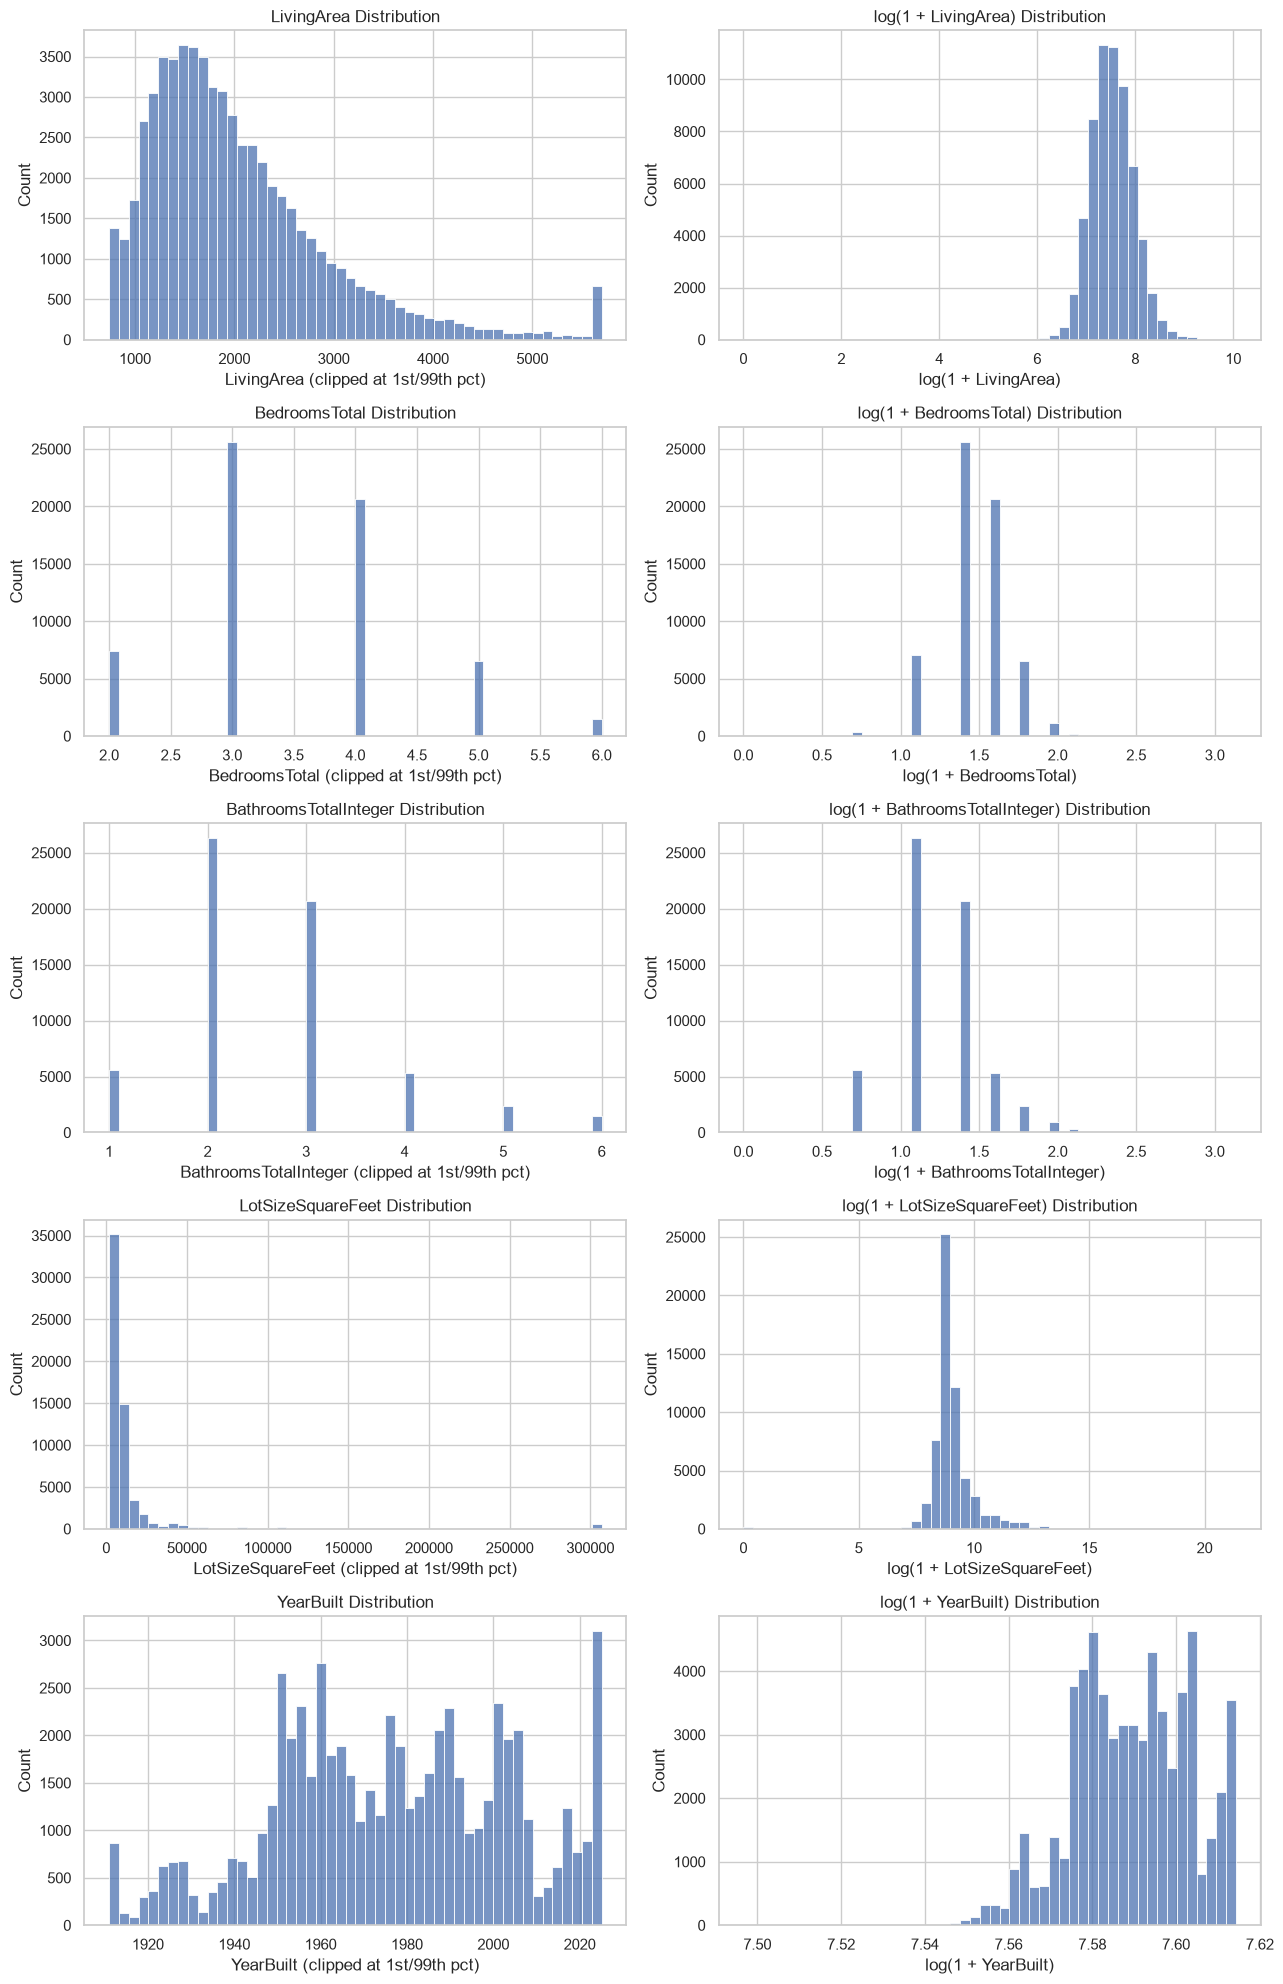

In [183]:
# Plot only the core numeric features for a concise EDA section.
# These are the most interpretable predictors for the first modeling pass.
core_numeric_plot_cols = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
]
core_numeric_plot_cols = [col for col in core_numeric_plot_cols if col in df.columns]

fig, axes = plt.subplots(len(core_numeric_plot_cols), 2, figsize=(13, 4 * len(core_numeric_plot_cols)))

for i, col in enumerate(core_numeric_plot_cols):
    values = df[col].dropna()

    # Clip the original-scale histogram only for readability.
    # The raw values remain unchanged in df.
    lower = values.quantile(0.01)
    upper = values.quantile(0.99)
    clipped_values = values.clip(lower, upper)

    sns.histplot(clipped_values, bins=50, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} Distribution")
    axes[i, 0].set_xlabel(f"{col} (clipped at 1st/99th pct)")
    axes[i, 0].set_ylabel("Count")

    # Log histogram is useful for right-skewed non-negative variables.
    non_negative_values = values[values >= 0]
    sns.histplot(np.log1p(non_negative_values), bins=50, ax=axes[i, 1])
    axes[i, 1].set_title(f"log(1 + {col}) Distribution")
    axes[i, 1].set_xlabel(f"log(1 + {col})")
    axes[i, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Categorical Feature Summary

In [184]:
# Summarize categorical columns by cardinality, missingness, and most common category.
# This informs encoding choices for preprocessing.
cat_summary = []

for col in categorical_cols:
    if col in df.columns:
        top_values = df[col].value_counts(dropna=False).head(5)
        cat_summary.append({
            "column": col,
            "n_unique": df[col].nunique(dropna=True),
            "missing_rate": df[col].isna().mean(),
            "top_value": top_values.index[0],
            "top_value_count": top_values.iloc[0],
            "top_5_values": ", ".join(map(str, top_values.index.tolist())),
        })

cat_summary_df = pd.DataFrame(cat_summary).sort_values("n_unique", ascending=False)
display(cat_summary_df)

# Show compact top-category tables for the most useful location/category fields.
# This is easier to interpret than plotting every categorical variable.
for col in ["CountyOrParish", "City", "PostalCode", "MLSAreaMajor"]:
    if col in df.columns:
        print(f"\nTop 10 values for {col}")
        display(df[col].value_counts(dropna=False).head(10).to_frame("count"))

,column,n_unique,missing_rate,top_value,top_value_count,top_5_values
2,PostalCode,1603,0.000016,92253,487,"92253, 92345, 92584, 92211, 92592"
3,MLSAreaMajor,969,0.141381,NaN,8727,"nan, 699 - Not Defined, SRCAR - Southwest Rive..."
0,City,912,0.000227,Los Angeles,2522,"Los Angeles, San Diego, Riverside, San Jose, O..."
6,HighSchoolDistrict,398,0.269396,NaN,16629,"nan, Los Angeles Unified, Other, Capistrano Un..."
5,Flooring,224,0.364265,NaN,22485,"nan, Carpet,Tile, Wood, Tile,Wood, Laminate"
1,CountyOrParish,58,0.000000,Los Angeles,15255,"Los Angeles, Riverside, San Diego, San Bernard..."
4,Levels,17,0.074894,One,35028,"One, Two, nan, ThreeOrMore, MultiSplit"



Top 10 values for CountyOrParish


,count
CountyOrParish,
Los Angeles,15255
Riverside,9727
San Diego,6885
San Bernardino,6633
Orange,5939
Contra Costa,2788
Alameda,2723
Ventura,2041
Santa Clara,1770



Top 10 values for City


,count
City,
Los Angeles,2522
San Diego,2170
Riverside,937
San Jose,888
Oakland,764
Menifee,730
Long Beach,603
Lancaster,598
Murrieta,583



Top 10 values for PostalCode


,count
PostalCode,
92253,487
92345,363
92584,354
92211,350
92592,325
92223,325
92596,318
92562,313
92336,293



Top 10 values for MLSAreaMajor


,count
MLSAreaMajor,
NaN,8727
699 - Not Defined,5296
SRCAR - Southwest Riverside County,3478
252 - Riverside,938
LAC - Lancaster,596
263 - Banning/Beaumont/Cherry Valley,542
274 - San Bernardino,528
VIC - Victorville,527
259 - Moreno Valley,513


### Location Summary

In [185]:
# County-level summary combines sample size and price level.
# This confirms that geography is likely a major predictor of ClosePrice.
county_summary = (
    df.dropna(subset=["CountyOrParish", "ClosePrice"])
    .groupby("CountyOrParish")
    .agg(
        n_sales=("ClosePrice", "size"),
        median_close_price=("ClosePrice", "median"),
        mean_close_price=("ClosePrice", "mean"),
    )
    .sort_values("n_sales", ascending=False)
)

print("Counties with the most sales")
display(county_summary.head(15))

print("Counties with the highest median ClosePrice, minimum 50 sales")
display(
    county_summary
    .query("n_sales >= 50")
    .sort_values("median_close_price", ascending=False)
    .head(15)
)

Counties with the most sales


,n_sales,median_close_price,mean_close_price
CountyOrParish,,,
Los Angeles,15255,1000886.0,1.477893e+06
Riverside,9727,630039.0,8.579658e+05
San Diego,6885,1075000.0,1.966173e+06
San Bernardino,6633,549990.0,6.768759e+05
Orange,5939,1425000.0,1.951671e+06
Contra Costa,2788,889000.0,1.232328e+06
Alameda,2723,1323000.0,1.446328e+06
Ventura,2041,975000.0,1.236888e+06
Santa Clara,1770,1882500.0,2.347178e+06


Counties with the highest median ClosePrice, minimum 50 sales


,n_sales,median_close_price,mean_close_price
CountyOrParish,,,
San Mateo,842,2147000.0,2.633683e+06
Santa Clara,1770,1882500.0,2.347178e+06
San Francisco,95,1428000.0,1.677861e+06
Orange,5939,1425000.0,1.951671e+06
Alameda,2723,1323000.0,1.446328e+06
Santa Cruz,377,1305000.0,1.570336e+06
San Diego,6885,1075000.0,1.966173e+06
Los Angeles,15255,1000886.0,1.477893e+06
Ventura,2041,975000.0,1.236888e+06


In [186]:
# ZIP code is more granular than county but has high cardinality.
# Use a minimum sales threshold so the ranking is not dominated by tiny samples.
zip_summary = (
    df.dropna(subset=["PostalCode", "ClosePrice"])
    .groupby("PostalCode")
    .agg(
        n_sales=("ClosePrice", "size"),
        median_close_price=("ClosePrice", "median"),
    )
    .sort_values("n_sales", ascending=False)
)

print("ZIP codes with the most sales")
display(zip_summary.head(15))

print("ZIP codes with the highest median ClosePrice, minimum 30 sales")
display(
    zip_summary
    .query("n_sales >= 30")
    .sort_values("median_close_price", ascending=False)
    .head(15)
)

ZIP codes with the most sales


,n_sales,median_close_price
PostalCode,,
92253,487,975000.0
92345,363,463000.0
92584,354,621000.0
92211,350,575000.0
92223,325,530000.0
92592,325,800000.0
92596,318,629990.0
92562,313,700000.0
92336,293,725000.0


ZIP codes with the highest median ClosePrice, minimum 30 sales


,n_sales,median_close_price
PostalCode,,
92657,42,9875000.0
90210,104,6925000.0
92625,50,6500000.0
90402,42,5100026.0
92067,73,4575000.0
92663,47,4450000.0
94024,31,4370000.0
90265,64,4275000.0
95070,54,4237500.0


# 5. Key features vs. Target variable

,pearson_corr,spearman_corr,missing_rate
LivingArea,0.118223,0.520977,0.000486
BathroomsTotalInteger,0.107541,0.484593,0.000016
BedroomsTotal,0.061007,0.372465,0.000000
Stories,0.028420,0.266901,0.105189
GarageSpaces,0.011348,0.242384,0.038119
Longitude,-0.005392,-0.229256,0.000146
AssociationFee,0.042470,0.224394,0.285386
ParkingTotal,0.002813,0.204997,0.000000
Latitude,-0.014020,-0.140862,0.000146
LotSizeSquareFeet,-0.000980,0.098715,0.017513


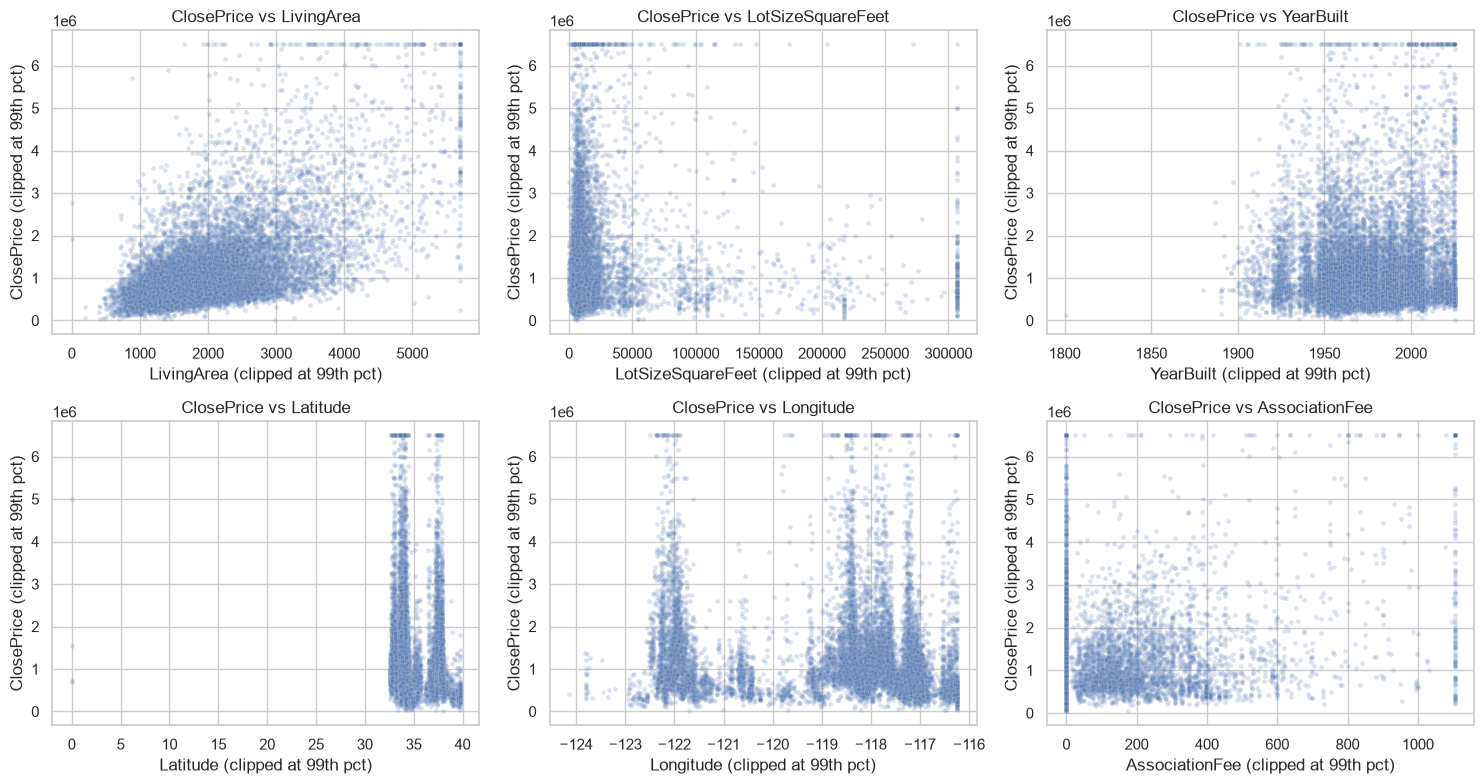

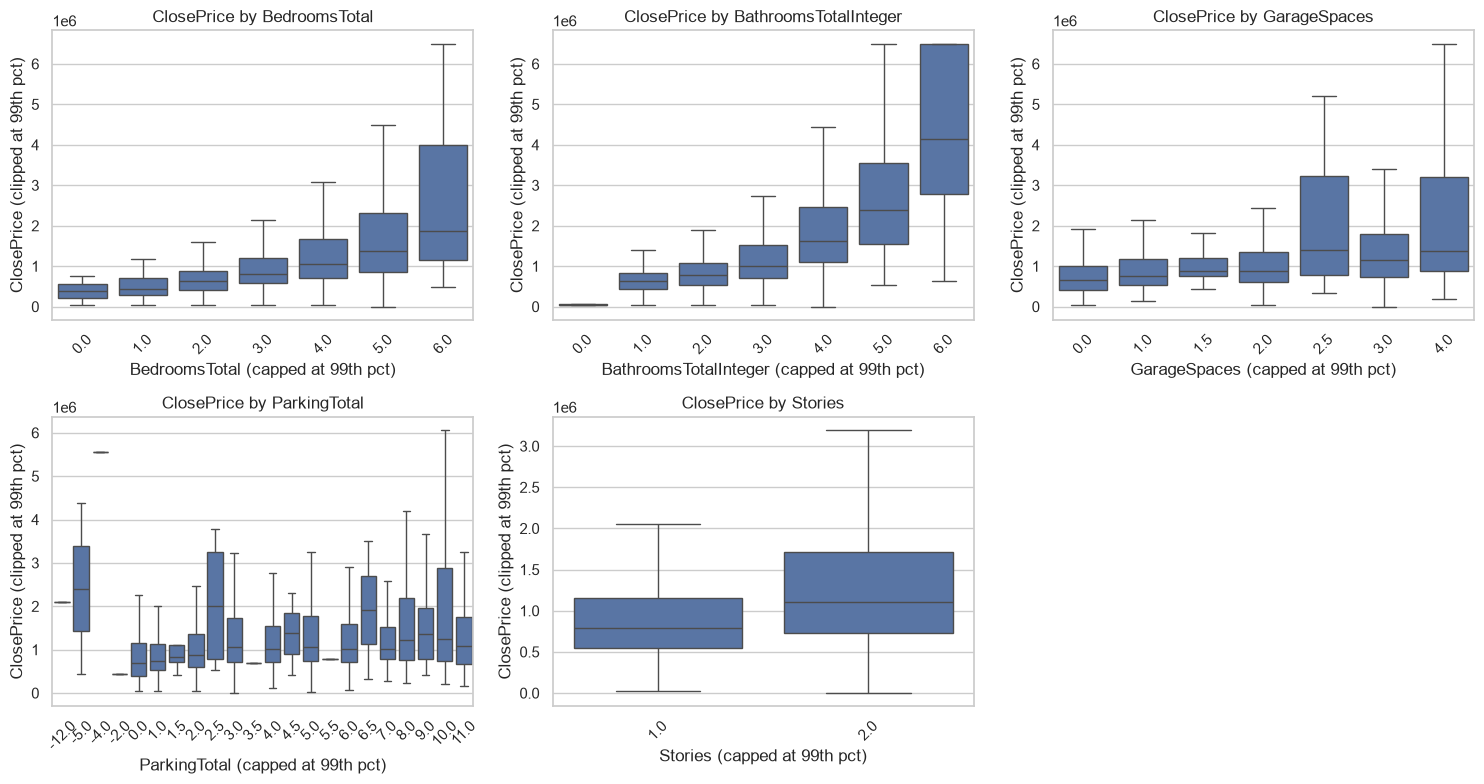

,feature_name,feature,n_sales,median_close_price
0,LivingArea,1001.0,6060,635000.0
1,LivingArea,1224.0,6068,730000.0
2,LivingArea,1397.0,6035,775000.0
3,LivingArea,1561.0,6031,810000.0
4,LivingArea,1731.0,6051,850000.0
5,LivingArea,1924.0,6046,900000.0
6,LivingArea,2155.0,6053,1000000.0
7,LivingArea,2439.0,6042,1150000.0
8,LivingArea,2846.0,6041,1300000.0
9,LivingArea,3686.0,6040,2148500.0


In [187]:
# Define model-relevant numeric features to compare directly with the target.
# This section focuses on interpretable property characteristics and location fields.
key_features = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "GarageSpaces",
    "ParkingTotal",
    "Stories",
    "AssociationFee",
]

key_features = [col for col in key_features if col in df.columns]

# Build a numeric-only analysis frame for correlations and plots.
feature_target_df = df[["ClosePrice"] + key_features].copy()

for col in feature_target_df.columns:
    feature_target_df[col] = pd.to_numeric(feature_target_df[col], errors="coerce")

# Keep only positive target values for target-feature relationship checks.
feature_target_df = feature_target_df[feature_target_df["ClosePrice"].gt(0)].copy()

# Compare Pearson and Spearman correlations.
# Spearman is often more useful in EDA because it captures monotonic relationships and is less sensitive to scale.
corr_summary = pd.DataFrame(
    {
        "pearson_corr": feature_target_df.corr(numeric_only=True)["ClosePrice"],
        "spearman_corr": feature_target_df.corr(method="spearman", numeric_only=True)["ClosePrice"],
        "missing_rate": feature_target_df.isna().mean(),
    }
).drop(index="ClosePrice")

corr_summary["abs_spearman_corr"] = corr_summary["spearman_corr"].abs()
corr_summary = corr_summary.sort_values("abs_spearman_corr", ascending=False)

display(corr_summary.drop(columns="abs_spearman_corr"))

# Use clipping and sampling for readable, fast plots. This affects plots only, not the raw data.
plot_df = feature_target_df.sample(
    n=min(15000, len(feature_target_df)),
    random_state=42,
).copy()

price_upper = feature_target_df["ClosePrice"].quantile(0.99)
plot_df["ClosePrice_clipped"] = plot_df["ClosePrice"].clip(upper=price_upper)

# Continuous features are shown with scatter plots.
continuous_features = [
    "LivingArea",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "AssociationFee",
]
continuous_features = [col for col in continuous_features if col in key_features]

n_cols = 3
n_rows = math.ceil(len(continuous_features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(continuous_features):
    # Clip x values only in the plot so extreme values do not hide the main relationship.
    x_upper = feature_target_df[col].quantile(0.99)
    x_values = plot_df[col].clip(upper=x_upper)

    sns.scatterplot(
        x=x_values,
        y=plot_df["ClosePrice_clipped"],
        alpha=0.2,
        s=12,
        ax=axes[i],
    )
    axes[i].set_title(f"ClosePrice vs {col}")
    axes[i].set_xlabel(f"{col} (clipped at 99th pct)")
    axes[i].set_ylabel("ClosePrice (clipped at 99th pct)")

for j in range(len(continuous_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Discrete/count-like features are shown with boxplots.
discrete_features = [
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "GarageSpaces",
    "ParkingTotal",
    "Stories",
]
discrete_features = [col for col in discrete_features if col in key_features]

n_cols = 3
n_rows = math.ceil(len(discrete_features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(discrete_features):
    temp = plot_df[[col, "ClosePrice_clipped"]].dropna().copy()
    cap = feature_target_df[col].quantile(0.99)
    temp[col] = temp[col].clip(upper=cap)

    sns.boxplot(data=temp, x=col, y="ClosePrice_clipped", ax=axes[i], showfliers=False)
    axes[i].set_title(f"ClosePrice by {col}")
    axes[i].set_xlabel(f"{col} (capped at 99th pct)")
    axes[i].set_ylabel("ClosePrice (clipped at 99th pct)")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(discrete_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Bin skewed continuous features into deciles and compare median target by bin.
# This makes nonlinear relationships easier to read than a dense scatter plot.
binned_features = ["LivingArea", "LotSizeSquareFeet", "YearBuilt"]
binned_features = [col for col in binned_features if col in key_features]

binned_summaries = []

for col in binned_features:
    temp = feature_target_df[[col, "ClosePrice"]].dropna().copy()
    temp = temp[temp[col].between(temp[col].quantile(0.01), temp[col].quantile(0.99))]
    temp["bin"] = pd.qcut(temp[col], q=10, duplicates="drop")

    summary = (
        temp.groupby("bin", observed=True)
        .agg(
            feature=(col, "median"),
            n_sales=("ClosePrice", "size"),
            median_close_price=("ClosePrice", "median"),
        )
        .reset_index(drop=True)
    )
    summary.insert(0, "feature_name", col)
    binned_summaries.append(summary)

binned_summary_df = pd.concat(binned_summaries, ignore_index=True)
display(binned_summary_df)

# 6. Additional EDA Checks

These checks focus on model-relevant relationships and data quality questions that should be resolved before preprocessing/modeling.

### Price per Square Foot

`ClosePrice / LivingArea` is useful for comparing properties with different sizes. It should only be computed when both `ClosePrice` and `LivingArea` are positive.

EDA only, not a model feature

,PricePerSqFt
count,61678.000000
mean,647.439252
std,4359.660439
min,0.000498
1%,166.358696
5%,221.476153
25%,342.589980
50%,527.732345
75%,738.910674
95%,1260.246605


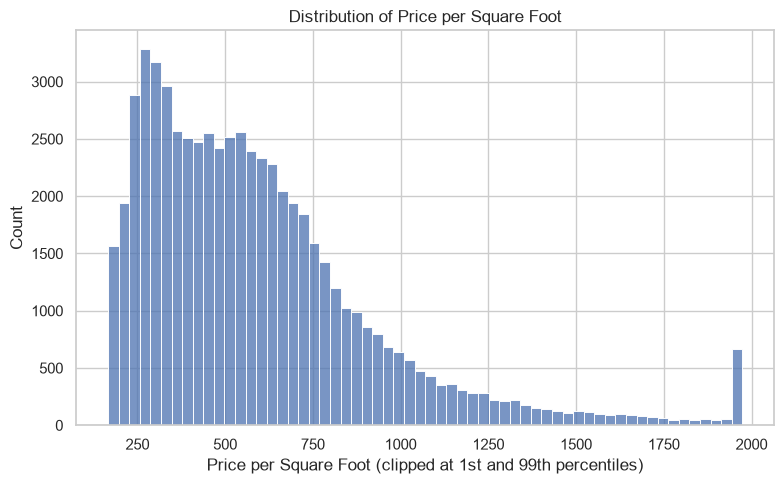

In [188]:
# Create a normalized price metric so properties of different sizes can be compared.
# Only compute this when both ClosePrice and LivingArea are positive; otherwise set it to NaN.
df["PricePerSqFt"] = np.where(
    (df["ClosePrice"] > 0) & (df["LivingArea"] > 0),
    df["ClosePrice"] / df["LivingArea"],
    np.nan,
)

# Summarize the full distribution, including tail percentiles.
# The 1st and 99th percentiles help identify suspiciously low/high price-per-sq-ft values.
price_per_sqft_summary = df["PricePerSqFt"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

display(price_per_sqft_summary.to_frame("PricePerSqFt"))

# Clip only for visualization so extreme values do not make the histogram unreadable.
# This does not change df["PricePerSqFt"] or remove any rows from the dataset.
psf_lower = df["PricePerSqFt"].quantile(0.01)
psf_upper = df["PricePerSqFt"].quantile(0.99)

plt.figure(figsize=(8, 5))
sns.histplot(df["PricePerSqFt"].clip(psf_lower, psf_upper), bins=60)
plt.xlabel("Price per Square Foot (clipped at 1st and 99th percentiles)")
plt.ylabel("Count")
plt.title("Distribution of Price per Square Foot")
plt.tight_layout()
plt.show()

,n_sales,median_price_per_sqft,median_close_price
CountyOrParish,,,
San Mateo,842,1219.722222,2147000.0
Santa Clara,1770,1080.851161,1882500.0
San Francisco,94,993.627343,1419000.0
Santa Cruz,377,740.909091,1305000.0
Alameda,2721,737.774030,1323000.0
Orange,5939,724.104075,1425000.0
Los Angeles,15216,632.553847,1000000.0
San Diego,6883,607.553366,1075000.0
Monterey,682,593.178031,940000.0


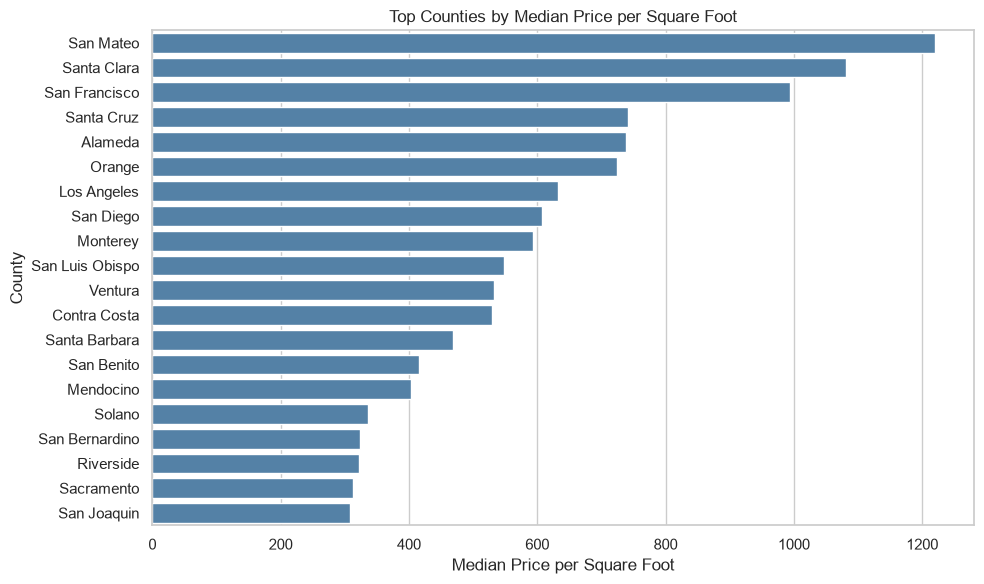

In [189]:
# Compare price per square foot by county.
# Require at least 50 sales so the ranking is not driven by counties with only a few records.
psf_by_county = (
    df.dropna(subset=["CountyOrParish", "PricePerSqFt"])
    .groupby("CountyOrParish")
    .agg(
        n_sales=("PricePerSqFt", "size"),
        median_price_per_sqft=("PricePerSqFt", "median"),
        median_close_price=("ClosePrice", "median"),
    )
    .query("n_sales >= 50")
    .sort_values("median_price_per_sqft", ascending=False)
)

# Display the most expensive counties on a size-adjusted basis.
display(psf_by_county.head(20))

# Plot the same ranking so regional differences are easier to scan visually.
plt.figure(figsize=(10, 6))
sns.barplot(
    data=psf_by_county.head(20).reset_index(),
    y="CountyOrParish",
    x="median_price_per_sqft",
    color="steelblue",
)
plt.xlabel("Median Price per Square Foot")
plt.ylabel("County")
plt.title("Top Counties by Median Price per Square Foot")
plt.tight_layout()
plt.show()

### County and City Median Price

Use a minimum sales threshold so small cities/counties do not dominate the ranking because of a few unusual transactions.

In [190]:
# Summarize median sale price by county and city.
# n_sales is kept in the table so we can judge whether each median is based on enough data.
county_price_summary = (
    df.dropna(subset=["CountyOrParish", "ClosePrice"])
    .groupby("CountyOrParish")
    .agg(
        n_sales=("ClosePrice", "size"),
        median_close_price=("ClosePrice", "median"),
        median_price_per_sqft=("PricePerSqFt", "median"),
    )
    .query("n_sales >= 50")
    .sort_values("median_close_price", ascending=False)
)

# City has higher cardinality than county, so the minimum sales threshold is especially important here.
city_price_summary = (
    df.dropna(subset=["City", "ClosePrice"])
    .groupby("City")
    .agg(
        n_sales=("ClosePrice", "size"),
        median_close_price=("ClosePrice", "median"),
        median_price_per_sqft=("PricePerSqFt", "median"),
    )
    .query("n_sales >= 50")
    .sort_values("median_close_price", ascending=False)
)

# Show the top rows from both summaries before plotting.
display(county_price_summary.head(20))
display(city_price_summary.head(20))

,n_sales,median_close_price,median_price_per_sqft
CountyOrParish,,,
San Mateo,842,2147000.0,1219.722222
Santa Clara,1770,1882500.0,1080.851161
San Francisco,95,1428000.0,993.627343
Orange,5939,1425000.0,724.104075
Alameda,2723,1323000.0,737.774030
Santa Cruz,377,1305000.0,740.909091
San Diego,6885,1075000.0,607.553366
Los Angeles,15255,1000886.0,632.553847
Ventura,2041,975000.0,532.931272


,n_sales,median_close_price,median_price_per_sqft
City,,,
Beverly Hills,125,5200000.0,1303.832084
Rancho Santa Fe,81,4550000.0,905.279207
Malibu,64,4275000.0,1295.082033
Newport Beach,210,4270000.0,1545.758810
Saratoga,54,4237500.0,1565.755486
Santa Monica,100,3875000.0,1686.520777
Pacific Palisades,54,3752438.0,1233.250559
Manhattan Beach,121,3750000.0,1492.365313
Palo Alto,95,3650000.0,2150.537634


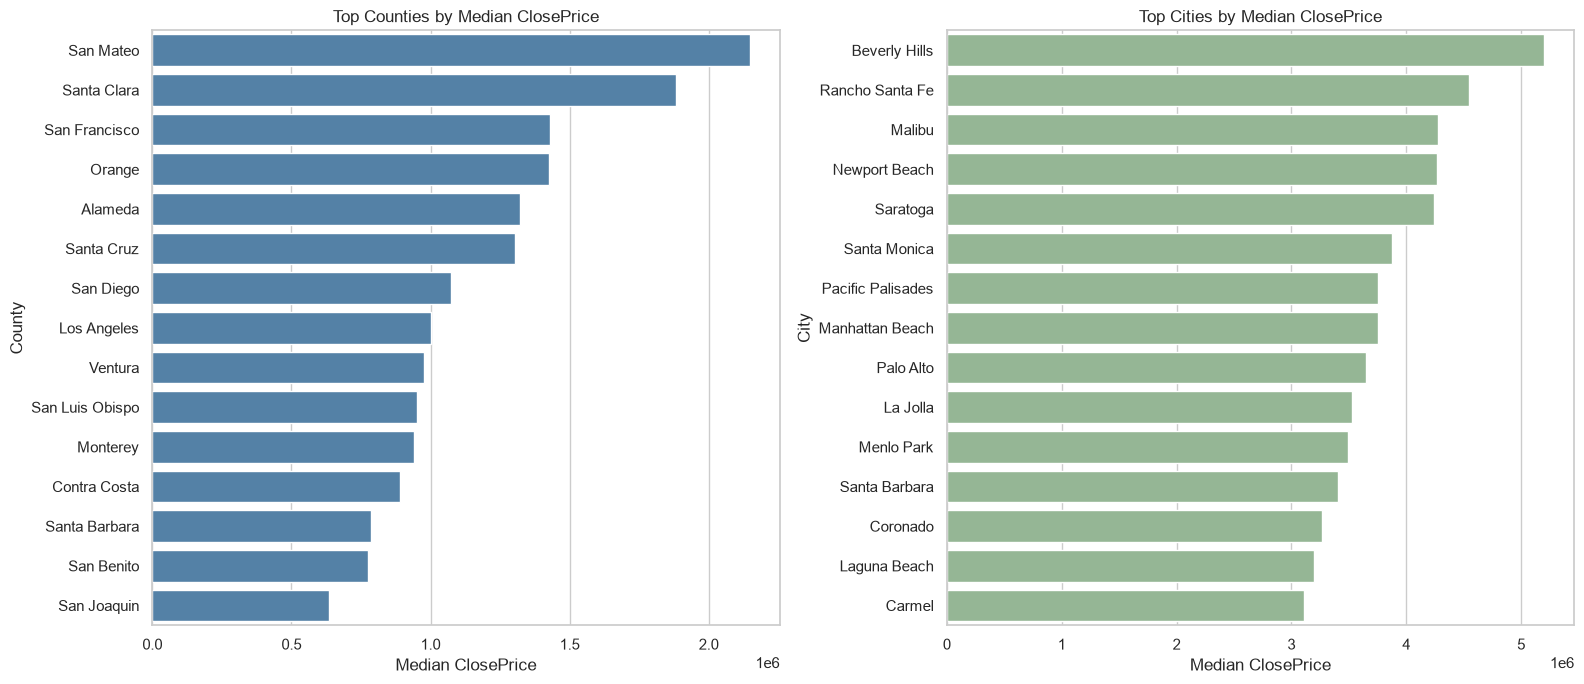

In [191]:
# Plot county and city medians side by side.
# These charts help identify high-price regions that may need strong geographic features in the model.
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(
    data=county_price_summary.head(15).reset_index(),
    y="CountyOrParish",
    x="median_close_price",
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title("Top Counties by Median ClosePrice")
axes[0].set_xlabel("Median ClosePrice")
axes[0].set_ylabel("County")

sns.barplot(
    data=city_price_summary.head(15).reset_index(),
    y="City",
    x="median_close_price",
    color="darkseagreen",
    ax=axes[1],
)
axes[1].set_title("Top Cities by Median ClosePrice")
axes[1].set_xlabel("Median ClosePrice")
axes[1].set_ylabel("City")

plt.tight_layout()
plt.show()

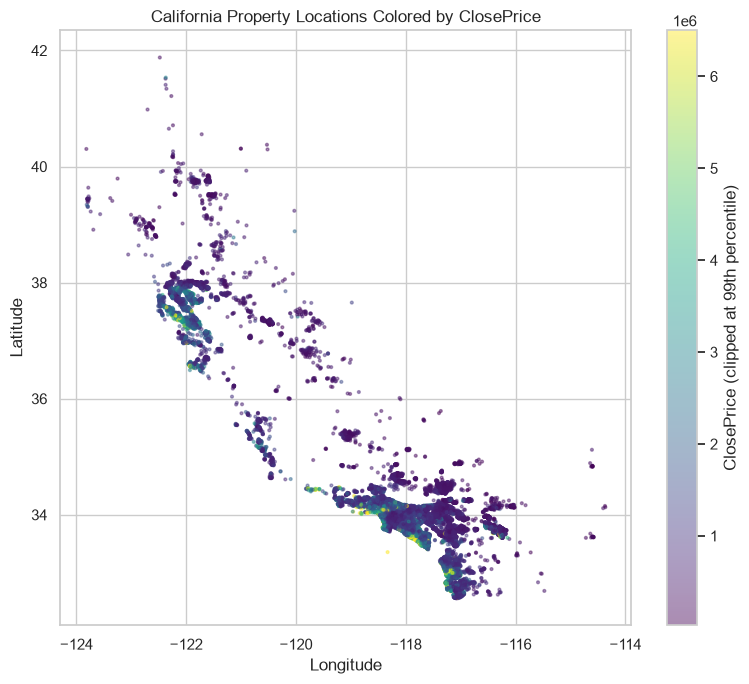

In [192]:
# Build a map-ready sample with valid coordinates and target values.
# The California bounds remove obvious coordinate errors before plotting.
map_sample = df.dropna(subset=["Latitude", "Longitude", "ClosePrice"]).copy()
map_sample = map_sample[
    map_sample["Latitude"].between(32.0, 42.5)
    & map_sample["Longitude"].between(-125.0, -114.0)
]

# Sample the rows so the scatter plot stays responsive in the notebook.
map_sample = map_sample.sample(n=min(20000, len(map_sample)), random_state=42)

# Clip color values only for visualization; otherwise a few luxury sales dominate the color scale.
map_sample["ClosePrice_clipped"] = map_sample["ClosePrice"].clip(
    upper=df["ClosePrice"].quantile(0.99)
)

plt.figure(figsize=(8, 7))
scatter = plt.scatter(
    map_sample["Longitude"],
    map_sample["Latitude"],
    c=map_sample["ClosePrice_clipped"],
    s=4,
    alpha=0.45,
    cmap="viridis",
)
plt.colorbar(scatter, label="ClosePrice (clipped at 99th percentile)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Property Locations Colored by ClosePrice")
plt.tight_layout()
plt.show()

### Time Coverage and Future Test Set


In [193]:
# Convert important date fields to datetime.
# These fields help us understand time coverage and identify potential leakage columns.
date_cols = [
    "CloseDate",
    "ListingContractDate",
    "PurchaseContractDate",
    "ContractStatusChangeDate",
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Check date ranges for each available date column.
# CloseDate defines the chronological split; later transaction dates may be leakage for modeling.
available_date_cols = [col for col in date_cols if col in df.columns]
date_range_summary = df[available_date_cols].agg(["min", "max"]).T

display(date_range_summary)

# Create a monthly close period for trend analysis and future train/test splitting.
df["CloseMonth"] = df["CloseDate"].dt.to_period("M").astype("string")

# Summarize monthly sample size and price levels.
# This helps decide whether the latest month is large enough and stable enough to use as a test set.
monthly_summary = (
    df.dropna(subset=["CloseMonth"])
    .groupby("CloseMonth")
    .agg(
        n_sales=("ClosePrice", "size"),
        median_close_price=("ClosePrice", "median"),
        mean_close_price=("ClosePrice", "mean"),
        median_price_per_sqft=("PricePerSqFt", "median"),
    )
    .reset_index()
    .sort_values("CloseMonth")
)

latest_month = monthly_summary["CloseMonth"].iloc[-1]
latest_month_rows = int(monthly_summary.loc[monthly_summary["CloseMonth"] == latest_month, "n_sales"].iloc[0])

print(f"Latest month available: {latest_month}")
print(f"Rows in latest month: {latest_month_rows:,}")

# Show recent months only to keep the train/test split decision focused.
display(monthly_summary.tail(18))

,min,max
CloseDate,2025-12-01,2026-05-31
ListingContractDate,2017-02-01,2026-05-30
PurchaseContractDate,2020-08-18,2026-05-30
ContractStatusChangeDate,2025-12-01,2026-05-31


Latest month available: 2026-05
Rows in latest month: 12,024


,CloseMonth,n_sales,median_close_price,mean_close_price,median_price_per_sqft
0,2025-12,10455,860000.0,1.195244e+06,510.582011
1,2026-01,7490,851691.5,1.280369e+06,498.734705
2,2026-02,8550,880000.0,1.393256e+06,528.317836
3,2026-03,11177,897000.0,1.332800e+06,529.733424
4,2026-04,12031,921000.0,1.502497e+06,545.330607
5,2026-05,12024,930000.0,1.309789e+06,542.237443


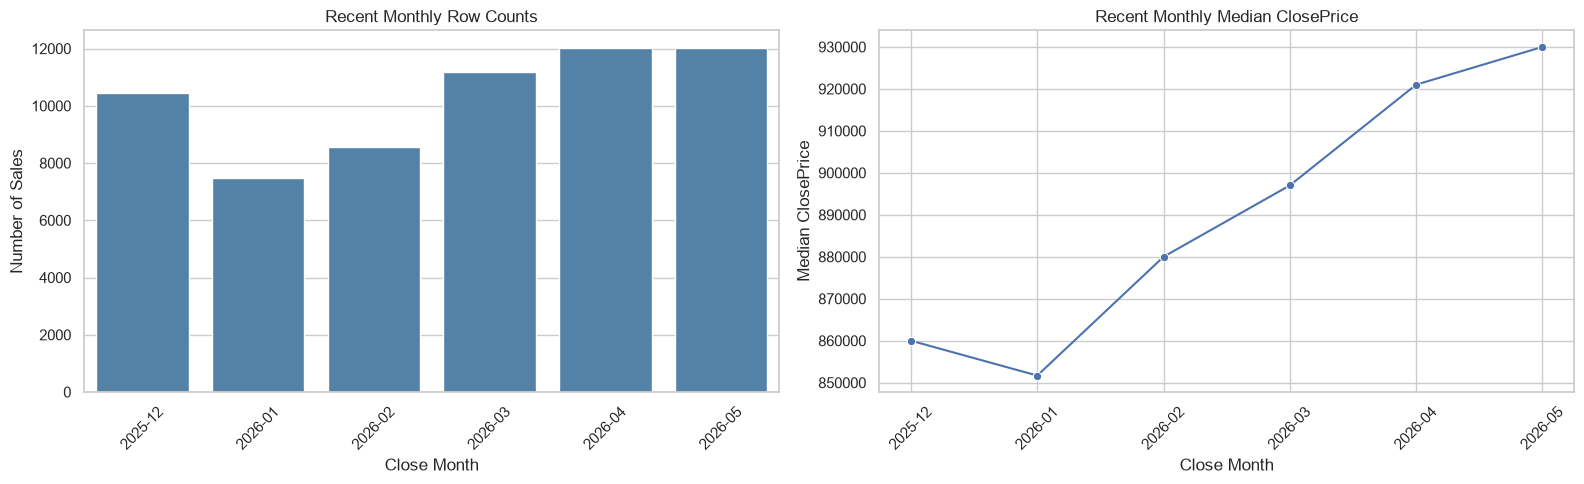

In [194]:
# Plot recent monthly sales volume and median price together.
# A sharp drop in the latest month could mean the month is incomplete and should not be used as test data.
recent_months = monthly_summary.tail(18)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=recent_months, x="CloseMonth", y="n_sales", color="steelblue", ax=axes[0])
axes[0].set_title("Recent Monthly Row Counts")
axes[0].set_xlabel("Close Month")
axes[0].set_ylabel("Number of Sales")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=recent_months, x="CloseMonth", y="median_close_price", marker="o", ax=axes[1])
axes[1].set_title("Recent Monthly Median ClosePrice")
axes[1].set_xlabel("Close Month")
axes[1].set_ylabel("Median ClosePrice")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Extreme Values in Key Numeric Features

These rows help distinguish true luxury or unusual properties from likely data errors before modeling.

In [195]:
# Select identifying and model-relevant fields for inspecting extreme numeric values.
# These rows are for manual review only; no rows are removed in this EDA notebook.
extreme_check_cols = [
    "ListingKey",
    "source_file",
    "CloseDate",
    "ClosePrice",
    "LivingArea",
    "LotSizeSquareFeet",
    "YearBuilt",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "City",
    "CountyOrParish",
    "PostalCode",
]
extreme_check_cols = [col for col in extreme_check_cols if col in df.columns]

# Inspect both tails for key numeric fields.
# Low values can reveal placeholder or missing-data encodings; high values can be true luxury/outlier records.
for feature in ["LivingArea", "LotSizeSquareFeet", "YearBuilt"]:
    if feature not in df.columns:
        continue

    print(f"\nLowest {feature} values")
    display(
        df.dropna(subset=[feature])
        .sort_values(feature, ascending=True)
        .loc[:, extreme_check_cols]
        .head(10)
    )

    print(f"Highest {feature} values")
    display(
        df.dropna(subset=[feature])
        .sort_values(feature, ascending=False)
        .loc[:, extreme_check_cols]
        .head(10)
    )


Lowest LivingArea values


,ListingKey,source_file,CloseDate,ClosePrice,LivingArea,LotSizeSquareFeet,YearBuilt,BedroomsTotal,BathroomsTotalInteger,City,CountyOrParish,PostalCode
14024,1134702110,CRMLSSold202512.csv,2025-12-22,1920000.0,0.0,11731.0,1967.0,3.0,3.0,Los Angeles,Los Angeles,90049
28619,1146102942,CRMLSSold202601.csv,2026-01-30,5280000.0,0.0,20364.0,1953.0,5.0,7.0,Pacific Palisades,Los Angeles,90272
123855,1125992245,CRMLSSold202605.csv,2026-05-13,6400000.0,0.0,1597780.0,1951.0,6.0,5.0,Ojai,Ventura,93023
81912,1155594867,CRMLSSold202604.csv,2026-04-10,1825000.0,0.0,4380.0,1910.0,4.0,4.0,Oakland,Alameda,94611
32879,1137140936,CRMLSSold202601.csv,2026-01-02,4088000.0,0.0,4841.0,2016.0,4.0,5.0,West Hollywood,Los Angeles,90048
87718,1154279551,CRMLSSold202604.csv,2026-04-24,385000.0,0.0,NaN,1984.0,3.0,1.0,Menifee,Riverside,92587
70195,1150504103,CRMLSSold202603.csv,2026-03-26,1470000.0,0.0,2249.0,1910.0,2.0,1.0,Venice,Los Angeles,90291
36736,1108366050,CRMLSSold202601.csv,2026-01-22,5500000.0,0.0,13481820.0,NaN,4.0,5.0,Lompoc,Santa Barbara,93436
13363,1136715994,CRMLSSold202512.csv,2025-12-04,7300000.0,0.0,8206.7,2022.0,6.0,8.0,Los Angeles,Los Angeles,90064
80751,1155901529,CRMLSSold202604.csv,2026-04-15,2850000.0,0.0,2002.0,1916.0,5.0,4.0,San Francisco,San Francisco,94110


Highest LivingArea values


,ListingKey,source_file,CloseDate,ClosePrice,LivingArea,LotSizeSquareFeet,YearBuilt,BedroomsTotal,BathroomsTotalInteger,City,CountyOrParish,PostalCode
124382,1048618285,CRMLSSold202605.csv,2026-05-15,21500000.0,23314.0,935669.0,2010.0,10.0,22.0,Alamo,Contra Costa,94507
64096,1152160462,CRMLSSold202603.csv,2026-03-25,30260000.0,19474.0,29589.0,2011.0,7.0,15.0,Beverly Hills,Los Angeles,90210
124323,1093899305,CRMLSSold202605.csv,2026-05-11,10380000.0,17230.0,116194.0,2024.0,10.0,16.0,Bradbury,Los Angeles,91008
53529,1127472951,CRMLSSold202602.csv,2026-02-27,8000000.0,17153.0,109771.2,2016.0,10.0,13.0,Bradbury,Los Angeles,91008
73981,1145917516,CRMLSSold202603.csv,2026-03-02,3500000.0,16499.0,23437.0,NaN,9.0,13.0,Los Angeles,Los Angeles,90049
76816,1119638038,CRMLSSold202603.csv,2026-03-10,15300000.0,16489.0,87120.0,2023.0,6.0,12.0,Malibu,Ventura,90265
36983,1065130596,CRMLSSold202601.csv,2026-01-14,31500000.0,15219.0,26297.0,2009.0,7.0,13.0,Newport Coast,Orange,92657
37349,1153105455,CRMLSSold202602.csv,2026-02-17,10300000.0,15037.0,193842.0,1991.0,8.0,12.0,Rancho Santa Fe,San Diego,92067
20715,1151475238,CRMLSSold202601.csv,2026-01-22,16426180.0,15015.0,57289.0,2026.0,7.0,9.0,Encino,Los Angeles,91436
82819,1155438031,CRMLSSold202604.csv,2026-04-30,60000000.0,15006.0,261796.0,NaN,7.0,14.0,Montecito,Santa Barbara,93108



Lowest LotSizeSquareFeet values


...

,ListingKey,source_file,CloseDate,ClosePrice,LivingArea,LotSizeSquareFeet,YearBuilt,BedroomsTotal,BathroomsTotalInteger,City,CountyOrParish,PostalCode
75012,1139858671,CRMLSSold202603.csv,2026-03-09,419000.0,1990.0,1.897474e+09,1990.0,3.0,3.0,Mountain Center,Riverside,92561
52726,1135672298,CRMLSSold202602.csv,2026-02-27,2863000.0,3549.0,1.897474e+09,1971.0,5.0,4.0,Orange,Orange,92869
33727,1134287822,CRMLSSold202601.csv,2026-01-02,617500.0,3035.0,1.802600e+09,1977.0,5.0,3.0,Madera,Madera,93636
32453,1138319070,CRMLSSold202601.csv,2026-01-05,690000.0,1260.0,1.058334e+09,1995.0,3.0,3.0,Valencia,Los Angeles,91354
32829,1137253906,CRMLSSold202601.csv,2026-01-14,435000.0,1372.0,1.053281e+09,2025.0,3.0,2.0,Apple Valley,San Bernardino,92308
16894,1125802267,CRMLSSold202512.csv,2025-12-16,665990.0,2549.0,1.047095e+09,2025.0,4.0,3.0,Apple Valley,San Bernardino,92307
59070,1153258105,CRMLSSold202603.csv,2026-03-17,1755000.0,3303.0,9.882022e+08,1977.0,4.0,3.0,Camarillo,Ventura,93010
16252,1127624974,CRMLSSold202512.csv,2025-12-18,699990.0,2932.0,9.493466e+08,2025.0,4.0,4.0,Apple Valley,San Bernardino,92307
53408,1128689767,CRMLSSold202602.csv,2026-02-13,422000.0,1701.0,9.173736e+08,2002.0,4.0,2.0,Victorville,San Bernardino,92395
49735,1146103592,CRMLSSold202602.csv,2026-02-02,445000.0,1372.0,8.189280e+08,2025.0,3.0,2.0,Apple Valley,San Bernardino,92307



Lowest YearBuilt values


,ListingKey,source_file,CloseDate,ClosePrice,LivingArea,LotSizeSquareFeet,YearBuilt,BedroomsTotal,BathroomsTotalInteger,City,CountyOrParish,PostalCode
51264,1142922952,CRMLSSold202602.csv,2026-02-03,310000.0,1221.0,6500.0,1801.0,3.0,1.0,San Bernardino,San Bernardino,92411
77342,1112214871,CRMLSSold202603.csv,2026-03-25,44000.0,898.0,3075.0,1801.0,2.0,1.0,Needles,San Bernardino,92363
10103,1139791571,CRMLSSold202512.csv,2025-12-16,123000.0,930.0,3750.0,1801.0,2.0,1.0,Needles,San Bernardino,92363
31188,1144191318,CRMLSSold202601.csv,2026-01-07,1390000.0,2750.0,6608.0,1854.0,6.0,5.0,Alameda,Alameda,94501
19540,1112572736,CRMLSSold202512.csv,2025-12-29,1193750.0,2700.0,5816566.8,1872.0,4.0,3.0,Lewiston,Trinity,96052
114235,1155541471,CRMLSSold202605.csv,2026-05-11,4090000.0,2890.0,3150.0,1874.0,3.0,3.0,San Francisco,San Francisco,94115
3984,1146092195,CRMLSSold202512.csv,2025-12-16,2000000.0,1295.0,3400.0,1876.0,3.0,2.0,Pacific Grove,Monterey,93950
12185,1137555124,CRMLSSold202512.csv,2025-12-31,1228160.0,1380.0,12632.4,1880.0,2.0,1.0,Mendocino,Mendocino,95460
99835,1137062631,CRMLSSold202604.csv,2026-04-02,720000.0,1559.0,5000.0,1880.0,5.0,2.0,Oakland,Alameda,94606
116555,1154860518,CRMLSSold202605.csv,2026-05-26,325000.0,1486.0,3049.0,1880.0,3.0,2.0,Chico,Butte,95928


Highest YearBuilt values


,ListingKey,source_file,CloseDate,ClosePrice,LivingArea,LotSizeSquareFeet,YearBuilt,BedroomsTotal,BathroomsTotalInteger,City,CountyOrParish,PostalCode
75618,1137037144,CRMLSSold202603.csv,2026-03-27,900183.0,2537.0,8346.0,2026.0,5.0,3.0,Corona,Riverside,92883
113922,1155642233,CRMLSSold202605.csv,2026-05-08,483495.0,1473.0,3900.0,2026.0,2.0,2.0,Beaumont,Riverside,92223
120208,1152308135,CRMLSSold202605.csv,2026-05-22,584830.0,1705.0,5326.0,2026.0,3.0,3.0,Winchester,Riverside,92596
94707,1151763953,CRMLSSold202604.csv,2026-04-17,569133.0,1900.0,2801.0,2026.0,4.0,3.0,Moreno Valley,Riverside,92555
29461,1145792656,CRMLSSold202601.csv,2026-01-26,733000.0,2723.0,4250.0,2026.0,5.0,3.0,Riverside,Riverside,92508
68588,1151073670,CRMLSSold202603.csv,2026-03-02,719317.0,1763.0,5130.0,2026.0,2.0,2.0,Tracy,San Joaquin,95377
36408,1113138097,CRMLSSold202601.csv,2026-01-13,1650000.0,2537.0,10990.0,2026.0,4.0,4.0,Walnut,Los Angeles,91789
122237,1149557196,CRMLSSold202605.csv,2026-05-08,538790.0,2583.0,7200.0,2026.0,4.0,3.0,Hesperia,San Bernardino,92345
60952,1152917668,CRMLSSold202603.csv,2026-03-30,430000.0,1509.0,6697.0,2026.0,4.0,2.0,Merced,Merced,95348
68636,1151065022,CRMLSSold202603.csv,2026-03-18,1442930.0,2378.0,8062.0,2026.0,2.0,4.0,Rancho Mission Viejo,Orange,92694


## EDA Summary

- Loaded 6 CRMLS sold CSV files covering `2025-12` to `2026-05`.
- Raw data contains `124,404` rows. After filtering to `Residential / SingleFamilyResidence`, `61,727` rows remain.
- `ClosePrice` has no missing or non-positive values, but it is highly right-skewed:
  - Median: about `$890K`.
  - Mean: about `$1.34M`.
  - 99th percentile: about `$6.5M`.
  - Maximum: about `$796M`, likely a data issue.
- Key data quality issues to handle before modeling:
  - `62` duplicated `ListingKey` values, creating `70` extra rows.
  - `24` records have coordinates outside the expected California range.
  - `LivingArea <= 0` and `LotSizeSquareFeet <= 0` appear in some records.
  - `LotSizeSquareFeet` and `ClosePrice` contain extreme outliers.
- Missingness varies across columns. High-missing columns, IDs, agent/office fields, and leakage-prone transaction fields should be excluded from the baseline model.
- Strong initial predictors include `LivingArea`, `BathroomsTotalInteger`, `BedroomsTotal`, garage/parking variables, and location-related features.
- Geography is a major price driver. High-price areas include Bay Area and coastal markets such as San Mateo, Santa Clara, Orange, Beverly Hills, Malibu, and Newport Beach.
- Latest available month is `2026-05` with `12,024` rows, so it is a reasonable candidate for a chronological test set.
- Modeling plan:
  - Deduplicate by `ListingKey`.
  - Clean obvious numeric errors and outliers.
  - Engineer location and property-age features.
  - Use previous months for training and `2026-05` for testing.
  - Compare models using raw `ClosePrice` and `log1p(ClosePrice)` as target.
